<a href="https://colab.research.google.com/github/FabioFavre/Pratica-6-PROCSIN/blob/main/Pratica_6_PROCSIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Funções Auxiliares para Análise de Filtros

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def analyze_filter(b, a, fs, title):
    # Resposta em frequência
    w, h = signal.freqz(b, a, worN=8000)
    freq = w * fs / (2 * np.pi)

    # Diagrama de Polos e Zeros
    z, p, k = signal.tf2zpk(b, a)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot Resposta em Frequência
    ax1.plot(freq, 20 * np.log10(np.abs(h)))
    ax1.set_title(f'Resposta em Frequência - {title}')
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.grid() # Add a grid

    # Plot Polos e Zeros
    theta = np.linspace(0, 2*np.pi, 100)
    ax2.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5)
    ax2.scatter(np.real(z), np.imag(z), s=50, marker='o', facecolors='none', edgecolors='b', label='Zeros')
    ax2.scatter(np.real(p), np.imag(p), s=50, marker='x', color='r', label='Polos')
    ax2.set_title('Diagrama de Polos e Zeros')
    ax2.set_xlabel('Real')
    ax2.set_ylabel('Imaginário')
    ax2.axis('equal')
    ax2.legend()
    ax2.grid()

    plt.tight_layout()
    plt.show()

## Exercício 1

### (a) Passa-baixas com $f_c = 1000$ Hz e $f_s = 20000$ Hz

Para um bloco de 2ª ordem, a função de transferência geral é dada pela colocação de polos complexos conjugados $p_{1,2} = r e^{\pm j 	heta}$. Para um filtro passa-baixas, costuma-se colocar zeros em $z = -1$ (frequência de Nyquist).

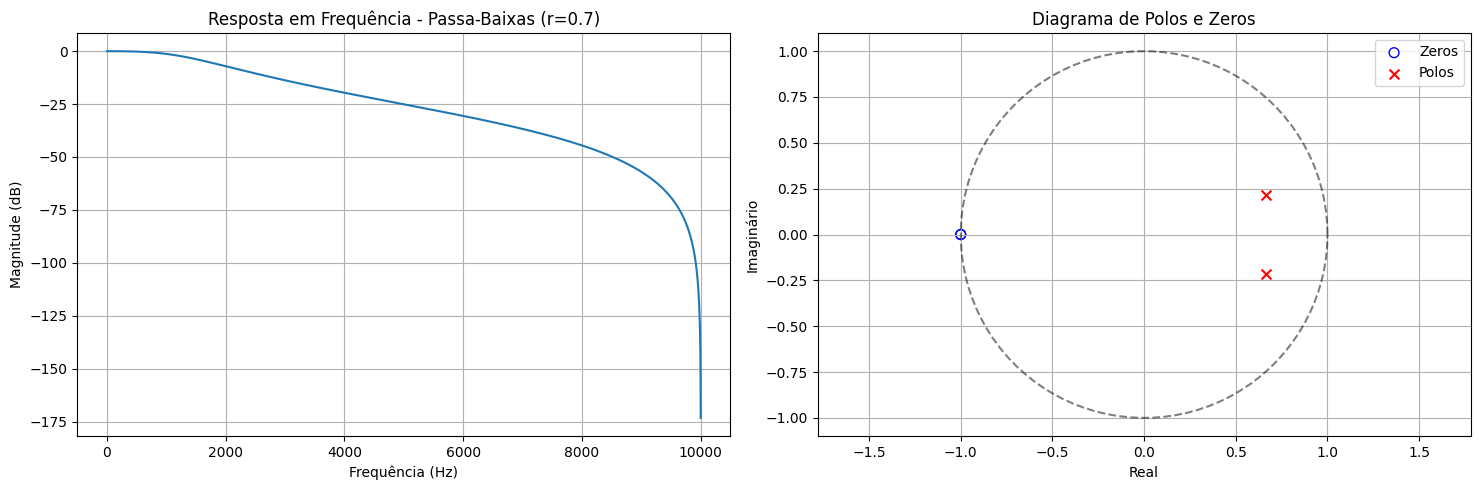

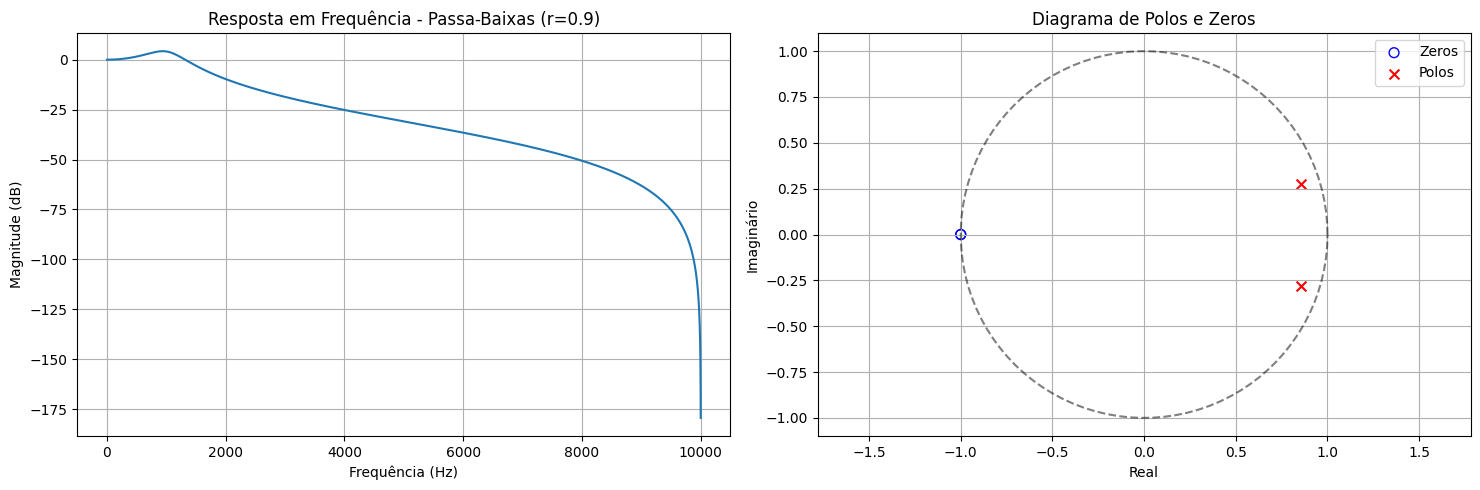

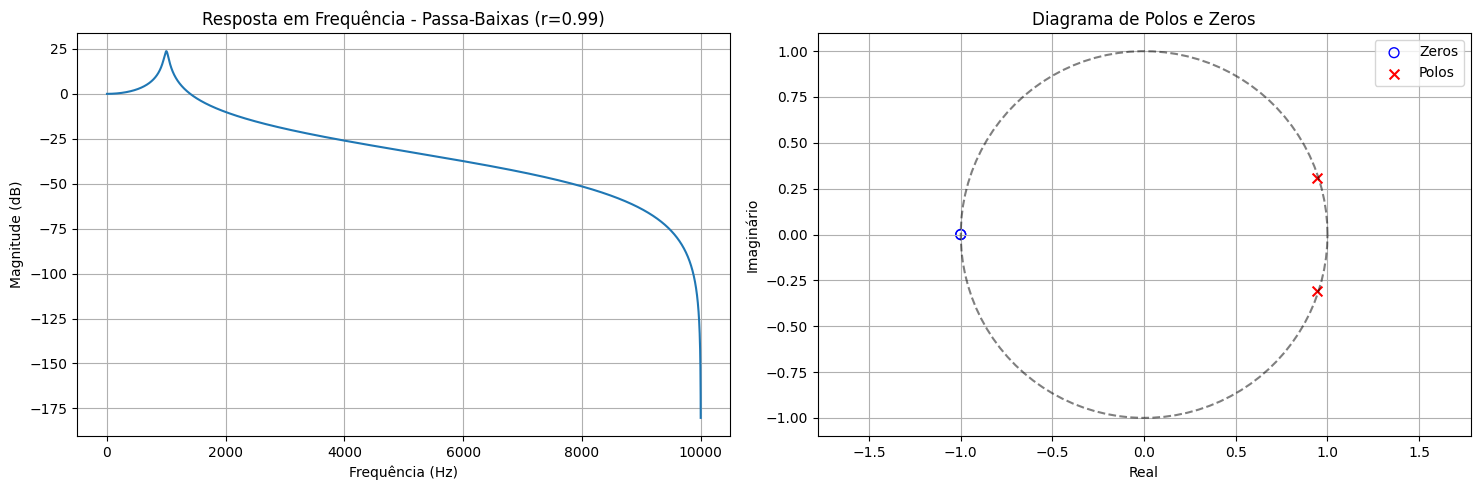

In [2]:
fs = 20000
fc = 1000
theta = 2 * np.pi * fc / fs
r_values = [0.7, 0.9, 0.99]

for r in r_values:
    # Polos: r * exp(j*theta) e r * exp(-j*theta)
    # Zeros: em z = -1 para atenuar altas frequências
    z = np.array([-1, -1])
    p = np.array([r * np.exp(1j * theta), r * np.exp(-1j * theta)])

    b, a = signal.zpk2tf(z, p, 1)
    # Normalização para ganho unitário em DC (w=0)
    w0, h0 = signal.freqz(b, a, [0])
    b = b / np.abs(h0)

    analyze_filter(b, a, fs, f'Passa-Baixas (r={r})')

### (b) Passa-altas com $f_c = 2000$ Hz e $f_s = 20000$ Hz

Para o filtro passa-altas, colocamos os polos em $e^{\pm j\theta}$ e os zeros em $z=1$ para bloquear baixas frequências.

/tmp/ipykernel_17042/3342672744.py:16: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(freq, 20 * np.log10(np.abs(h)))


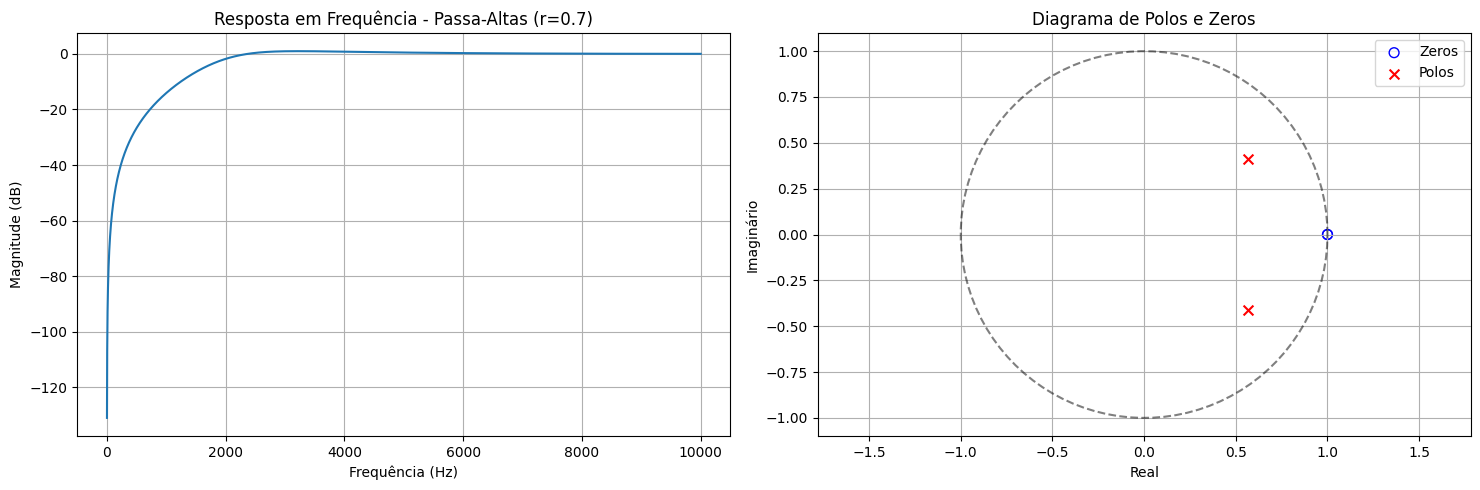

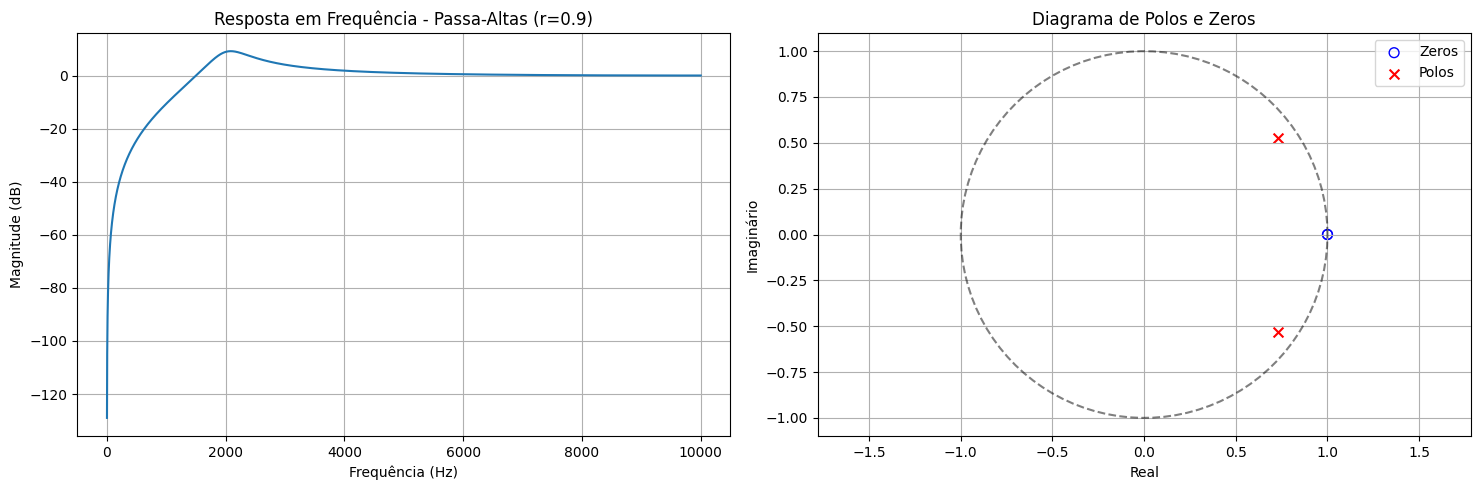

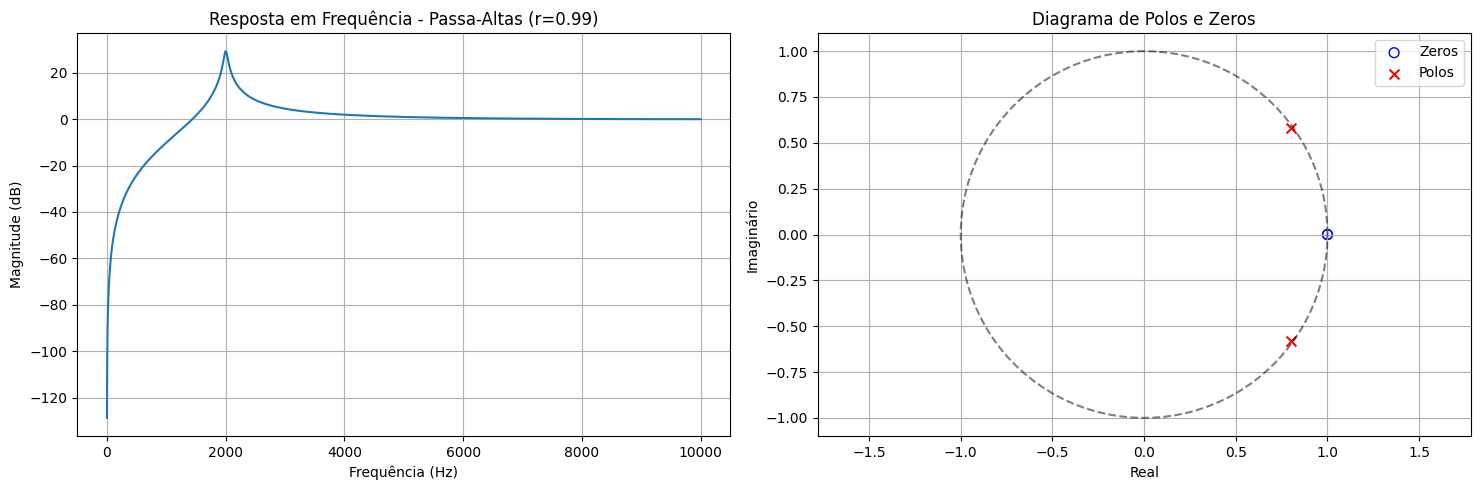

In [3]:
fs = 20000
fc = 2000
theta = 2 * np.pi * fc / fs
r_values = [0.7, 0.9, 0.99]

for r in r_values:
    # Polos: r * exp(j*theta) e r * exp(-j*theta)
    # Zeros: em z = 1 para atenuar baixas frequências (DC)
    z = np.array([1, 1])
    p = np.array([r * np.exp(1j * theta), r * np.exp(-1j * theta)])

    b, a = signal.zpk2tf(z, p, 1)
    # Normalização para ganho unitário em Nyquist (w=pi)
    w_nyq, h_nyq = signal.freqz(b, a, [np.pi])
    b = b / np.abs(h_nyq)

    analyze_filter(b, a, fs, f'Passa-Altas (r={r})')

**Comentários sobre seletividade, estabilidade e largura de banda:**

1. **Seletividade:** Conforme o parâmetro $r$ se aproxima de 1, a transição entre a banda de rejeição e a banda de passagem torna-se mais abrupta, aumentando a seletividade.
2. **Estabilidade:** Todos os filtros são estáveis, pois os polos estão dentro do círculo unitário ($r < 1$). No entanto, para $r=0.99$, o sistema está mais próximo da instabilidade (maior sensibilidade numérica).
3. **Largura de Banda:** O aumento de $r$ estreita a largura de banda da região de transição, tornando o filtro mais focado na frequência de corte desejada.

### (c) Passa-faixas com $f_c = 7000$ Hz e $f_s = 20000$ Hz

Para o passa-faixas de 2ª ordem, usamos zeros em $z=1$ e $z=-1$.

/tmp/ipykernel_17042/3342672744.py:16: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(freq, 20 * np.log10(np.abs(h)))


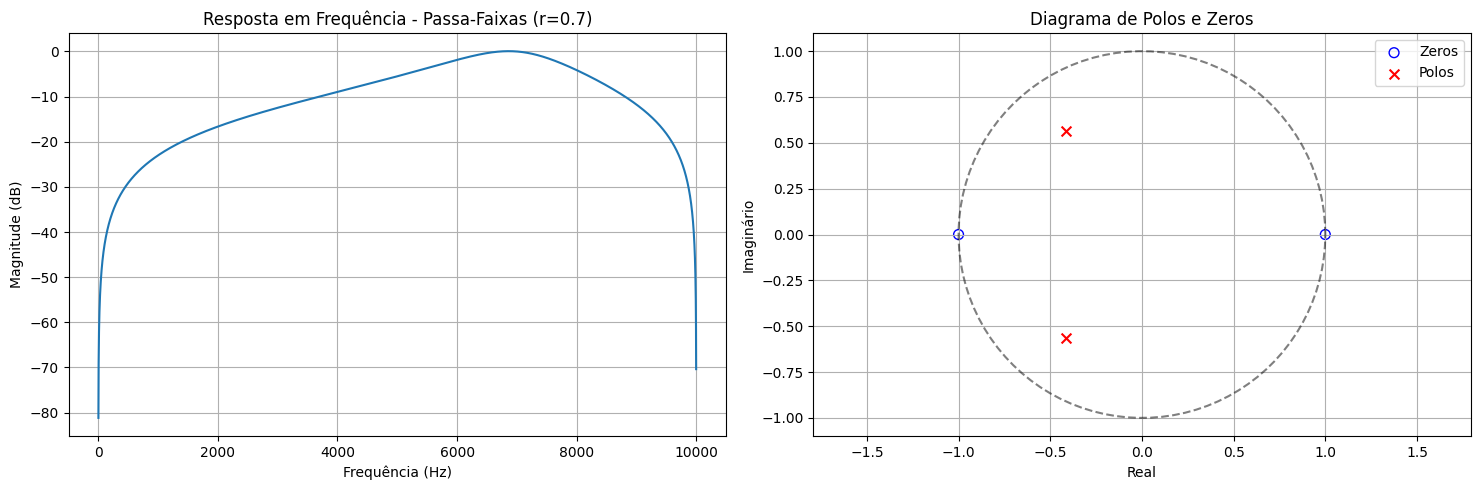

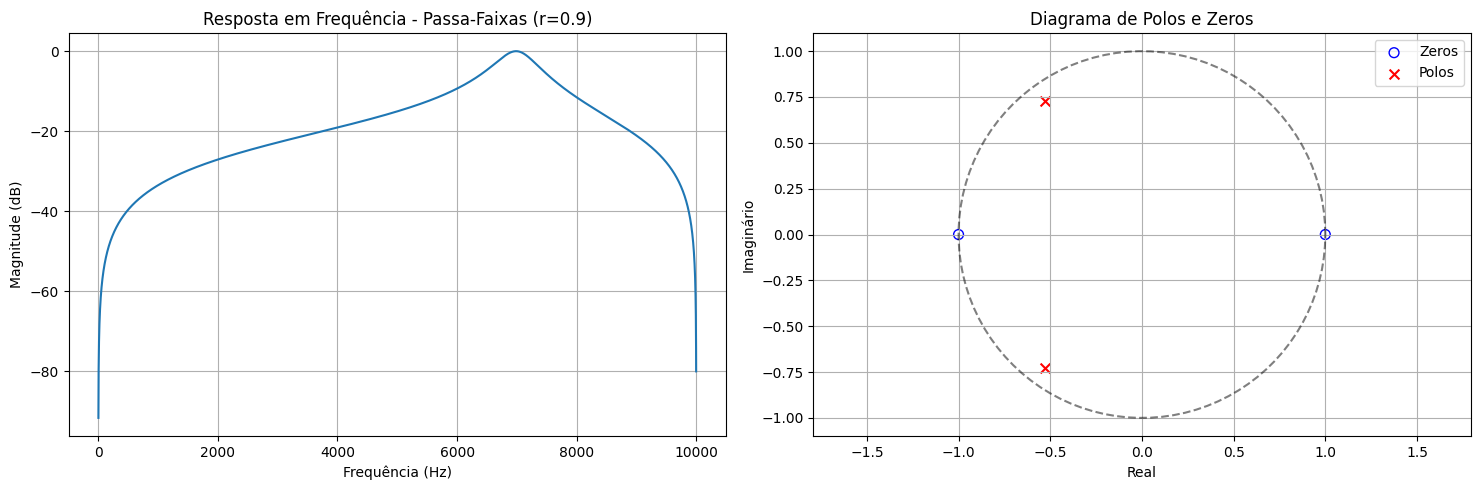

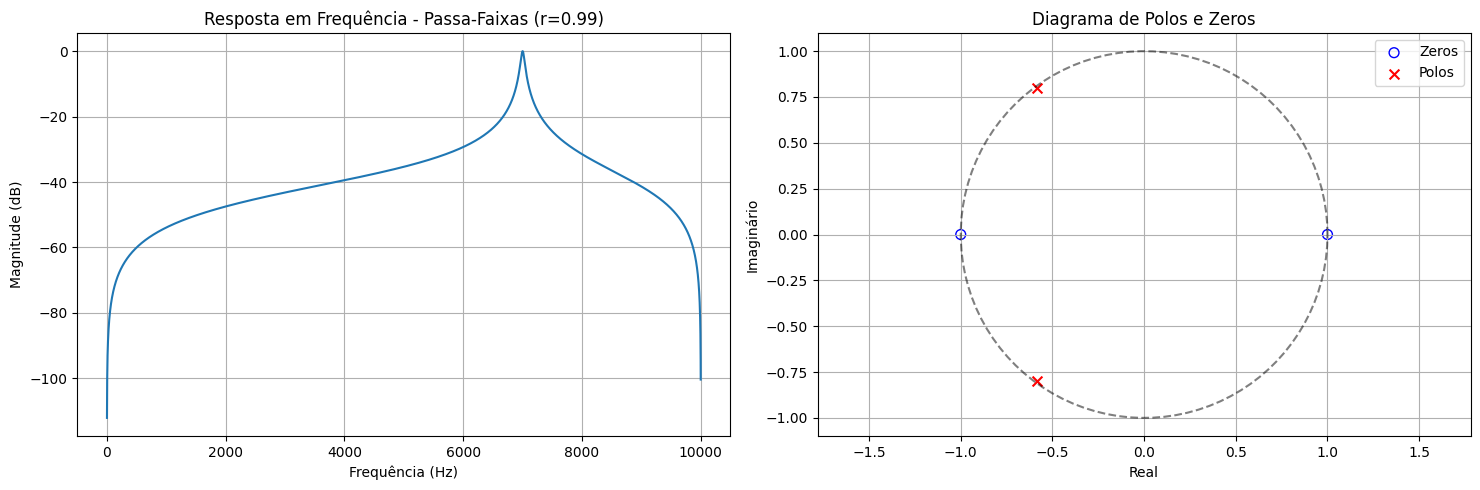

In [4]:
fs = 20000
fc = 7000
theta = 2 * np.pi * fc / fs
r_values = [0.7, 0.9, 0.99]

for r in r_values:
    z = np.array([1, -1])
    p = np.array([r * np.exp(1j * theta), r * np.exp(-1j * theta)])
    b, a = signal.zpk2tf(z, p, 1)

    # Normalização no pico (theta)
    w_peak, h_peak = signal.freqz(b, a, [theta])
    b = b / np.abs(h_peak)

    analyze_filter(b, a, fs, f'Passa-Faixas (r={r})')

### (d) Notch com $f_c = 3000$ Hz e $f_s = 20000$ Hz

Para o filtro Notch, os zeros são colocados em $e^{\pm j\theta}$ (sobre o círculo unitário).

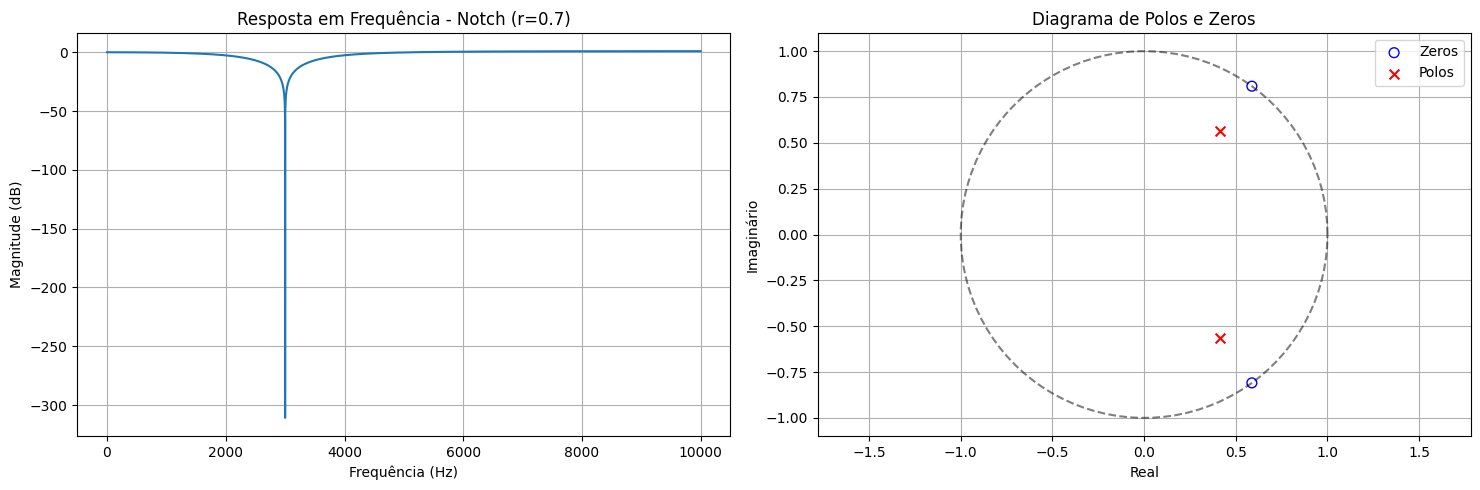

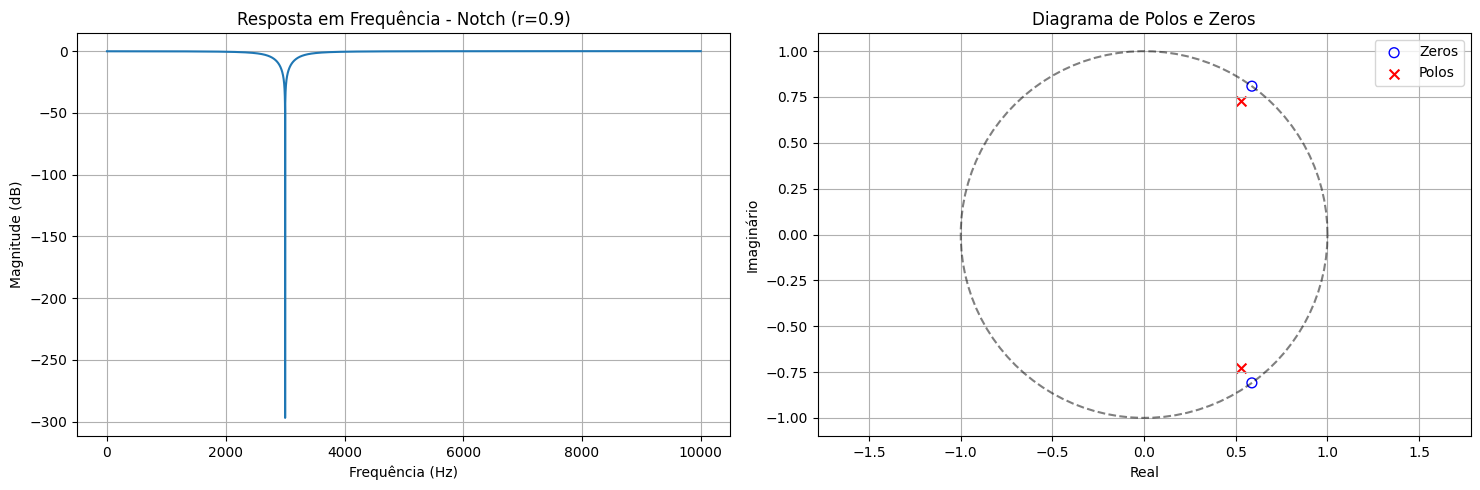

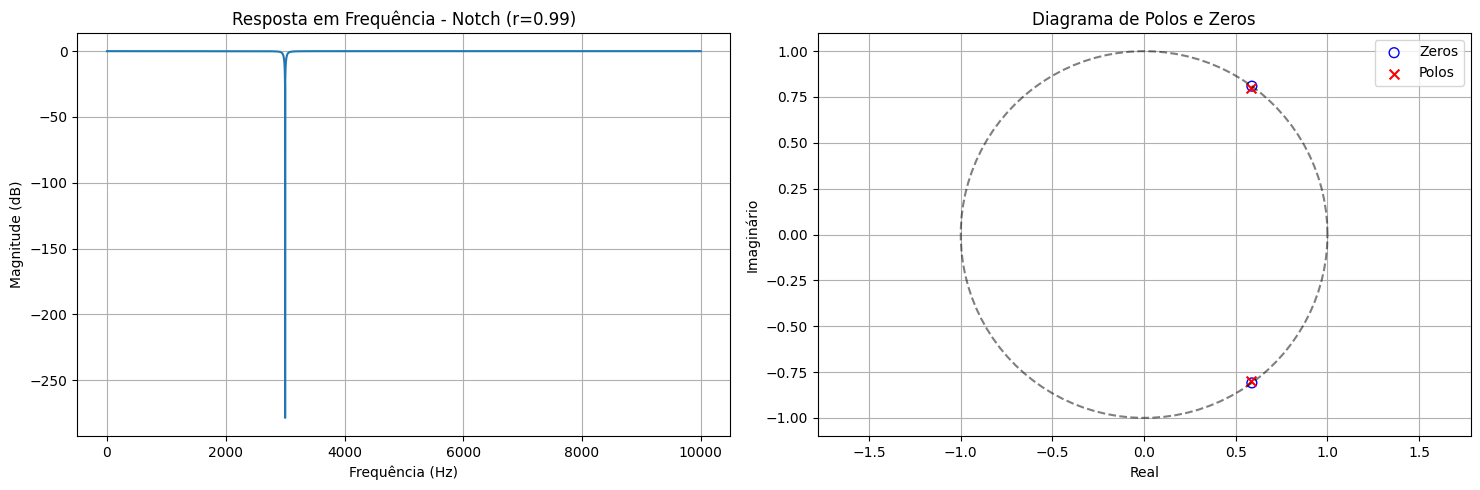

In [5]:
fs = 20000
fc = 3000
theta = 2 * np.pi * fc / fs
r_values = [0.7, 0.9, 0.99]

for r in r_values:
    # Zeros no círculo unitário para rejeição total
    z = np.array([np.exp(1j * theta), np.exp(-1j * theta)])
    # Polos na mesma fase, mas com magnitude r
    p = np.array([r * np.exp(1j * theta), r * np.exp(-1j * theta)])

    b, a = signal.zpk2tf(z, p, 1)

    # Normalização em DC
    w_dc, h_dc = signal.freqz(b, a, [0])
    b = b / np.abs(h_dc)

    analyze_filter(b, a, fs, f'Notch (r={r})')

## Exercício 2

### Projeto de Filtro Passa-Faixas em Cascata ($f_{c1}=6000$ Hz, $f_{c2}=8000$ Hz)

Para projetar um filtro com banda passante entre 6000 e 8000 Hz, utilizaremos uma cascata de dois blocos de 2ª ordem: um focado na frequência inferior e outro na superior, ou um projeto via protótipo analógico convertido para digital (Butterworth).

/tmp/ipykernel_17042/3342672744.py:16: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(freq, 20 * np.log10(np.abs(h)))


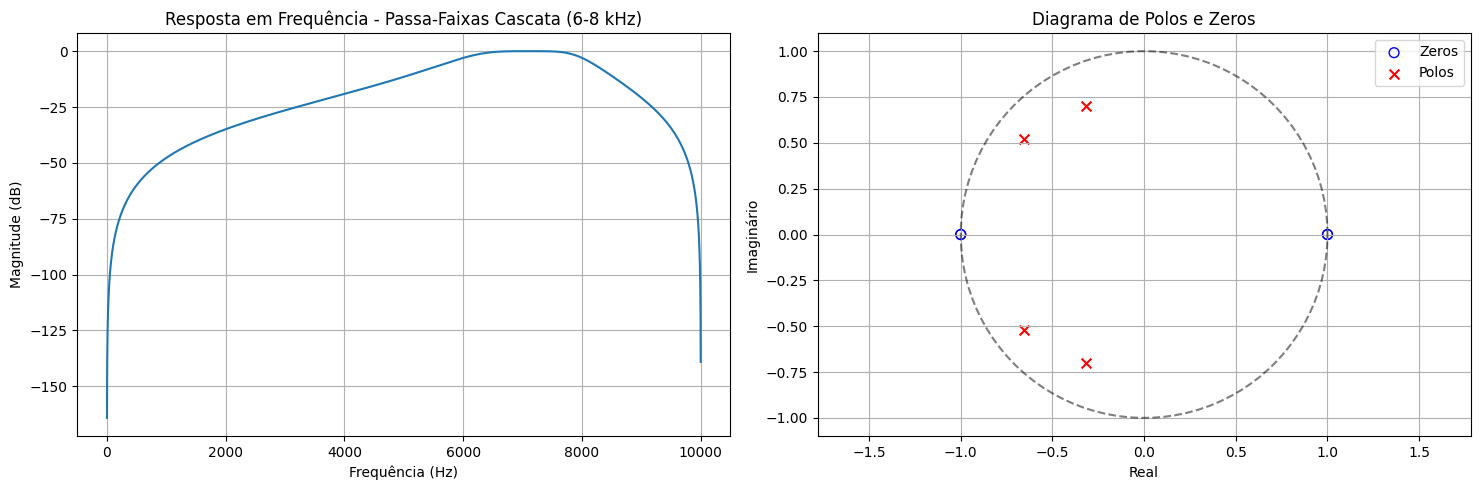

In [6]:
fs = 20000
fc1 = 6000
fc2 = 8000

# Projeto de um filtro Butterworth de 4ª ordem (cascata de dois blocos de 2ª ordem)
# utilizando a função signal.butter com output='sos' (Second-Order Sections)
sos = signal.butter(2, [fc1, fc2], btype='bandpass', fs=fs, output='sos')

# Para análise, convertemos SOS para função de transferência única (apenas para visualização)
b_total, a_total = signal.sos2tf(sos)

analyze_filter(b_total, a_total, fs, f'Passa-Faixas Cascata (6-8 kHz)')

**Comparação com o filtro da Questão 1:**

1. **Seletividade:** O filtro em cascata (4ª ordem total) apresenta uma queda muito mais íngreme fora da banda de passagem comparado ao filtro de 2ª ordem da Questão 1.
2. **Banda de Passagem:** A resposta é mais plana dentro da faixa de 6000-8000 Hz, enquanto o filtro de 2ª ordem possui um pico mais acentuado em uma única frequência central.
3. **Diagrama de Polos e Zeros:** Observamos dois pares de polos complexos conjugados, cada um contribuindo para moldar as bordas da banda passante.

## Exercício 3

### Projeto de Filtro Rejeita-Faixa em Paralelo ($f_{c1}=1000$ Hz, $f_{c2}=4000$ Hz)

Um filtro rejeita-faixa pode ser construído somando a saída de um filtro passa-baixas (com $f_c = 1000$ Hz) e um filtro passa-altas (com $f_c = 4000$ Hz).

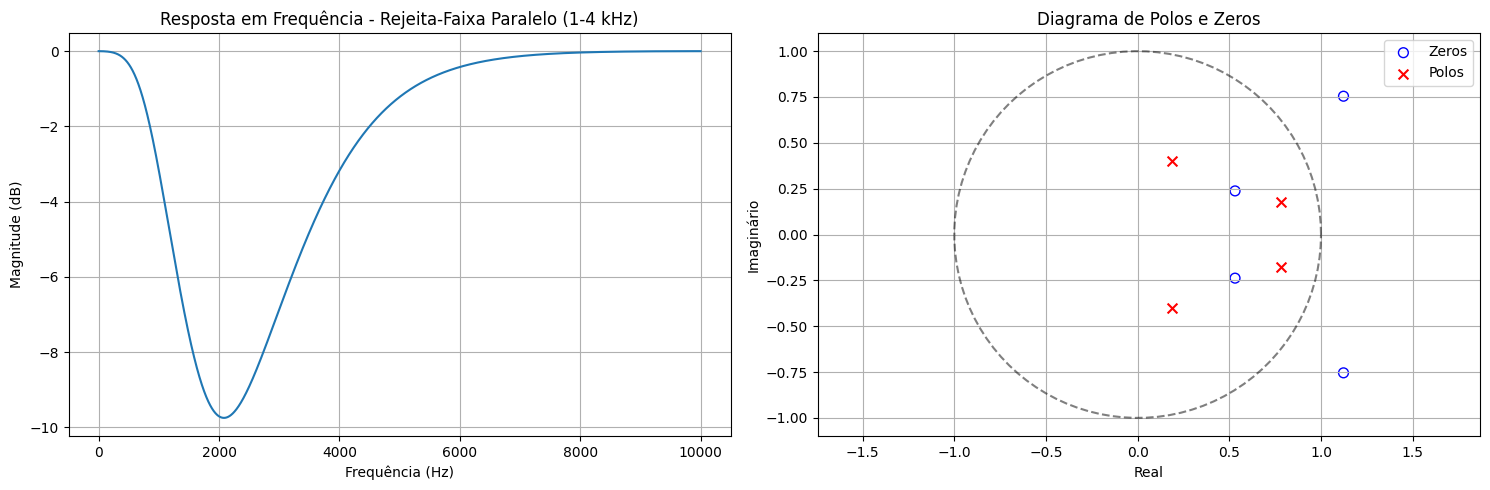

In [7]:
fs = 20000
fc1 = 1000
fc2 = 4000

# Projeto usando Butterworth para garantir bandas planas
# Ordem 2 para cada (resultando em ordem 4 no total)
b_lp, a_lp = signal.butter(2, fc1, btype='low', fs=fs)
b_hp, a_hp = signal.butter(2, fc2, btype='high', fs=fs)

# Em paralelo, as funções de transferência se somam: H(z) = H_lp(z) + H_hp(z)
# H(z) = (b_lp/a_lp) + (b_hp/a_hp) = (b_lp*a_hp + b_hp*a_lp) / (a_lp*a_hp)
b_par = np.polyadd(np.polymul(b_lp, a_hp), np.polymul(b_hp, a_lp))
a_par = np.polymul(a_lp, a_hp)

analyze_filter(b_par, a_par, fs, 'Rejeita-Faixa Paralelo (1-4 kHz)')

**Comparação com o filtro Notch da Questão 1:**

1. **Largura da Rejeição:** O filtro notch da questão 1 é extremamente estreito (rejeita apenas uma frequência específica). O filtro rejeita-faixa projetado aqui remove uma banda larga de frequências entre 1 e 4 kHz.
2. **Complexidade:** Este filtro utiliza uma estrutura paralela que resulta em uma ordem superior (4ª ordem), refletida no maior número de polos e zeros no diagrama.
3. **Transição:** As bandas de transição são definidas pela ordem dos filtros individuais (passa-baixas e passa-altas) utilizados na soma.

## Exercício 4

### Quantização de Coeficientes

Vamos analisar o impacto de representar os coeficientes dos filtros (Questões 2 e 3) com um número limitado de bits ($b \in \{2, 4, 8, 16, 32\}$).

/tmp/ipykernel_17042/2038800833.py:14: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h_orig)), label='Original (Float)', linewidth=2, color='black')


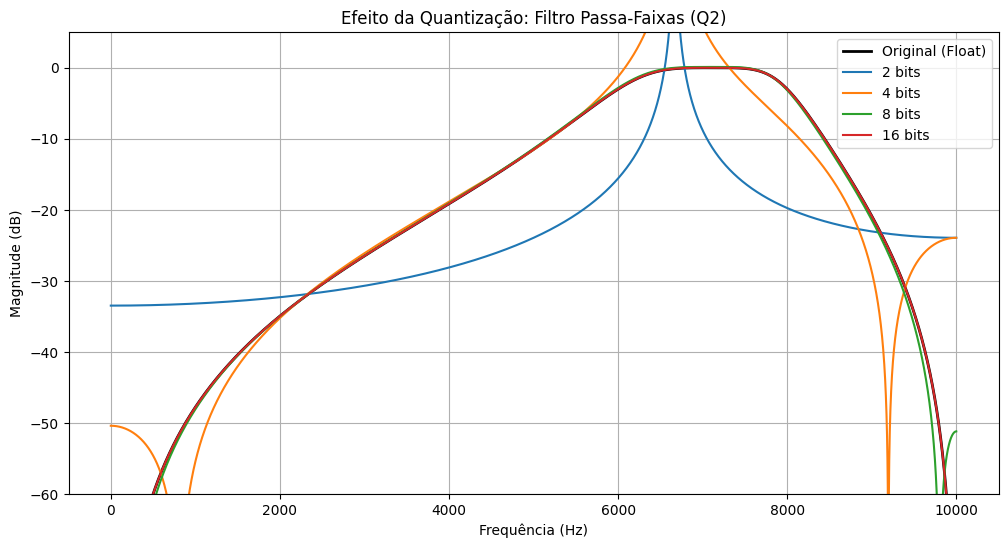

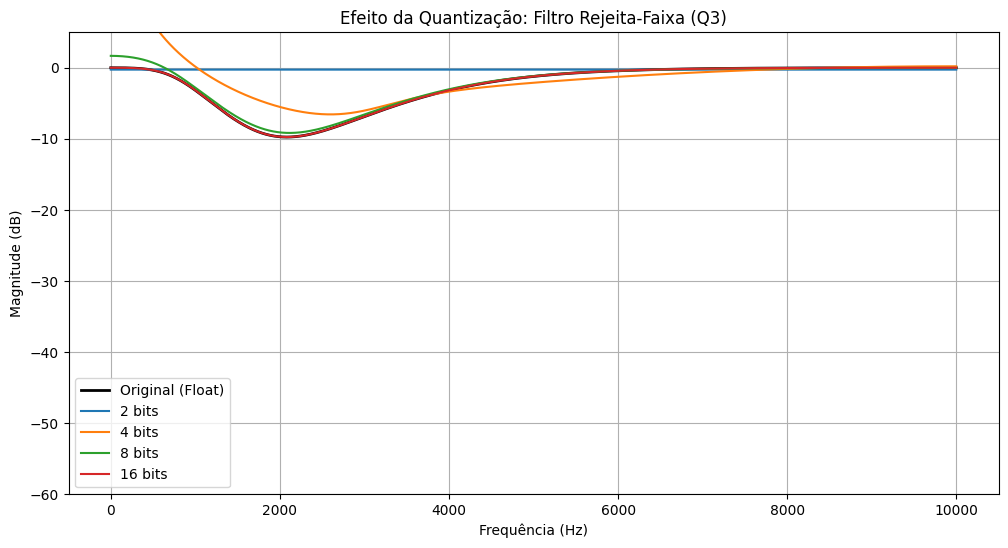

In [8]:
def quantize_coeffs(coeffs, bits):
    if bits >= 32: return coeffs # Assume 32-bit as float original
    max_val = np.max(np.abs(coeffs))
    # Escalonamento para o range do inteiro de b bits
    q_levels = 2**(bits - 1) - 1
    quantized = np.round(coeffs / max_val * q_levels) * (max_val / q_levels)
    return quantized

def test_quantization(b_orig, a_orig, fs, label):
    bits_list = [2, 4, 8, 16, 32]
    plt.figure(figsize=(12, 6))

    w, h_orig = signal.freqz(b_orig, a_orig, worN=8000)
    plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h_orig)), label='Original (Float)', linewidth=2, color='black')

    for b in bits_list:
        if b == 32: continue
        bq = quantize_coeffs(b_orig, b)
        aq = quantize_coeffs(a_orig, b)

        w, h = signal.freqz(bq, aq, worN=8000)
        plt.plot(w * fs / (2 * np.pi), 20 * np.log10(np.abs(h) + 1e-10), label=f'{b} bits')

    plt.title(f'Efeito da Quantização: {label}')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.ylim([-60, 5])
    plt.legend()
    plt.grid()
    plt.show()

# Testando para o filtro da Questão 2
test_quantization(b_total, a_total, fs, 'Filtro Passa-Faixas (Q2)')

# Testando para o filtro da Questão 3
test_quantization(b_par, a_par, fs, 'Filtro Rejeita-Faixa (Q3)')

**Análise da Sensibilidade Numérica:**

1. **Baixa Resolução (2-4 bits):** O filtro torna-se completamente instável ou perde totalmente sua característica de magnitude. Os polos podem sair do círculo unitário devido ao erro de arredondamento nos coeficientes do denominador.
2. **Resolução Média (8 bits):** A resposta em frequência começa a se aproximar da original, mas ainda apresenta desvios significativos (ripple) e deslocamento das frequências de corte.
3. **Alta Resolução (16-32 bits):** A resposta é virtualmente idêntica à original.
4. **Vantagem de SOS:** Implementar em cascata de 2ª ordem (como feito na Q2) reduz drasticamente a sensibilidade à quantização em comparação com a forma direta de ordem superior.

## Exercício 5

### (a) Geração do sinal contaminado $y(t)$ e (b) Análise Espectral

Vamos processar o arquivo `handel.wav`. As interferências são:
- Baixa frequência: $100$ Hz ($0.05 \cos(200\pi t)$)
- Alta frequência: $2000$ Hz ($0.075 \sin(4000\pi t)$)
- Ruído branco: $\sigma^2 \in \{10^{-2}, 10^{-1}, 1\}$

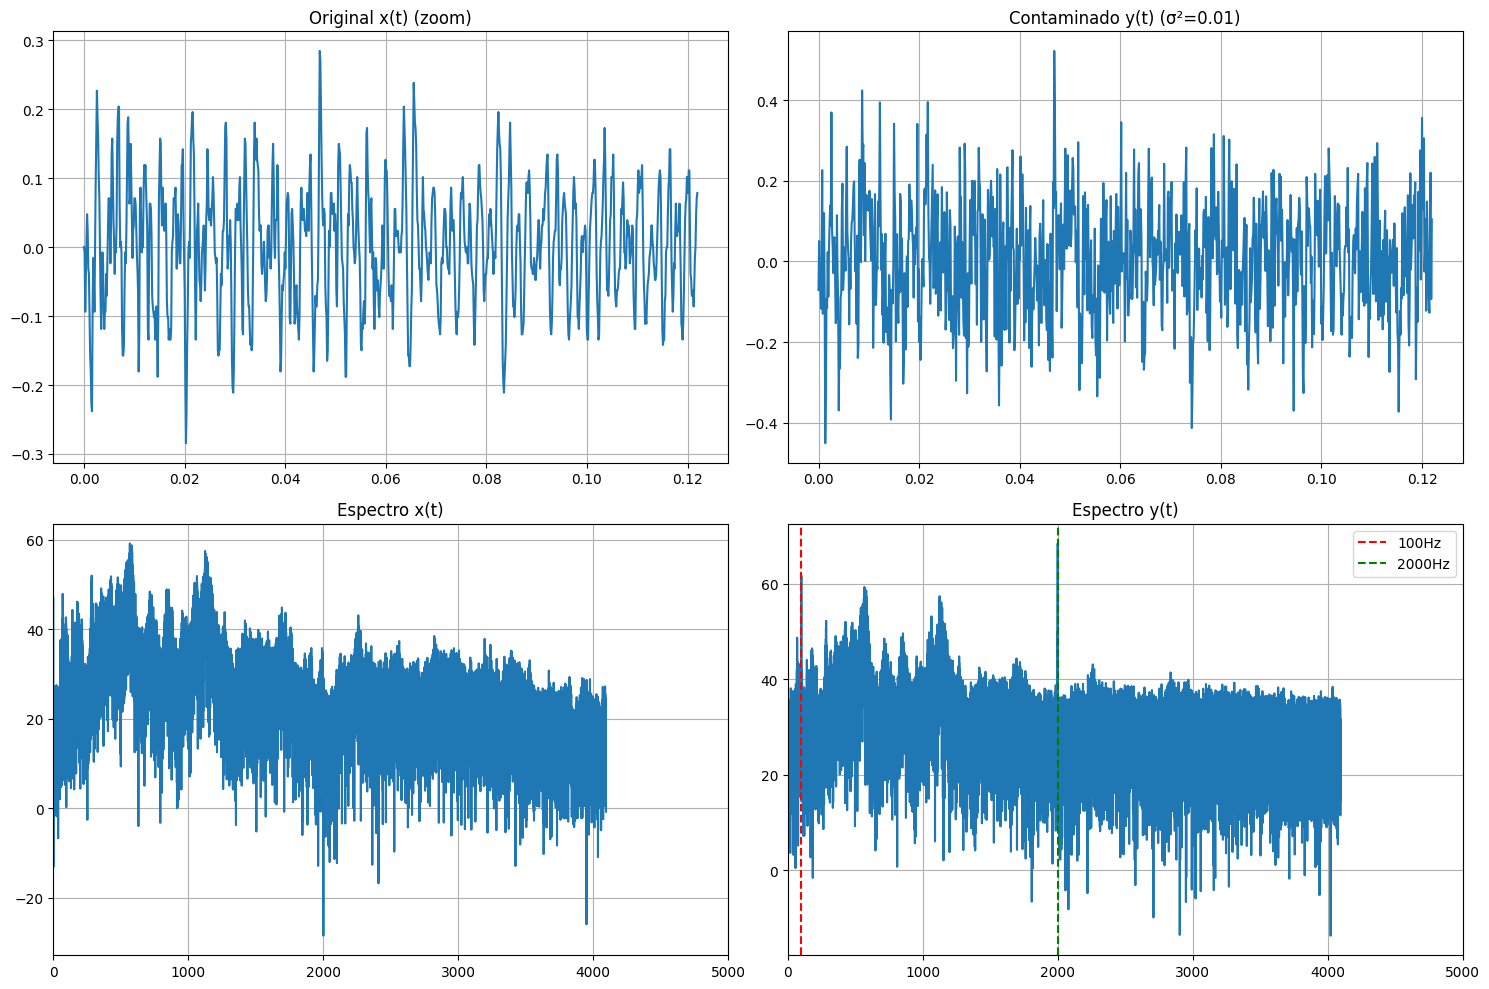

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq

# Carregar áudio
fs_audio, x_t = wavfile.read('/content/handel.wav')
x_t = x_t / np.max(np.abs(x_t)) # Normalização

t = np.arange(len(x_t)) / fs_audio

# Interferências senoidais
i1 = 0.05 * np.cos(200 * np.pi * t)
i2 = 0.075 * np.sin(4000 * np.pi * t)

variances = [0.01, 0.1, 1.0]
y_signals = []

for var in variances:
    noise = np.random.normal(0, np.sqrt(var), len(x_t))
    y_t = x_t + i1 + i2 + noise
    y_signals.append(y_t)

# Visualização para o caso σ² = 0.01
y_t_ex = y_signals[0]
N = len(x_t)
X_f = fft(x_t)
Y_f = fft(y_t_ex)
freqs = fftfreq(N, 1/fs_audio)

plt.figure(figsize=(15, 10))

# Tempo
plt.subplot(2, 2, 1)
plt.plot(t[:1000], x_t[:1000])
plt.title('Original x(t) (zoom)')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(t[:1000], y_t_ex[:1000])
plt.title('Contaminado y(t) (σ²=0.01)')
plt.grid()

# Frequência
plt.subplot(2, 2, 3)
plt.plot(freqs[:N//2], 20*np.log10(np.abs(X_f[:N//2]) + 1e-6))
plt.title('Espectro x(t)')
plt.xlim([0, 5000])
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(freqs[:N//2], 20*np.log10(np.abs(Y_f[:N//2]) + 1e-6))
plt.title('Espectro y(t)')
plt.axvline(100, color='r', linestyle='--', label='100Hz')
plt.axvline(2000, color='g', linestyle='--', label='2000Hz')
plt.xlim([0, 5000])
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Análise Espectral (5b):**

1. **Filtros Notch:** Devem ser usados para remover as interferências tonais em 100 Hz e 2000 Hz, pois são picos de frequência muito estreitos.
2. **Passa-Baixas/Passa-Faixas:** Podem ser usados para limitar a banda do sinal de áudio e remover parte do ruído branco de alta frequência que está fora da faixa útil do áudio original.
3. **Limitações do Ruído Branco:** O ruído branco está presente em todas as frequências. Filtros IIR podem remover interferências específicas, mas o ruído sobreposto à banda de áudio (in-band noise) não pode ser removido sem distorcer o sinal original.

### (c) Projeto do Sistema de Filtragem e (d) Recuperação do Sinal

Projetaremos dois filtros Notch de 2ª ordem em cascata com $r=0.99$ para garantir alta seletividade (remoção da interferência sem afetar muito o áudio adjacente).

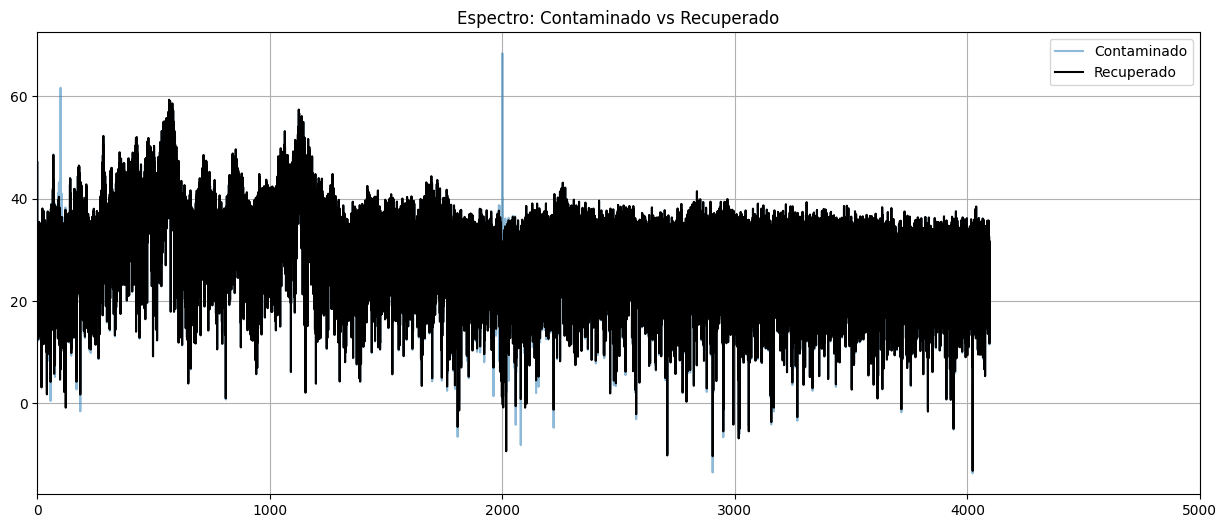

In [10]:
def design_notch(f_notch, fs, r=0.99):
    theta = 2 * np.pi * f_notch / fs
    z = np.array([np.exp(1j * theta), np.exp(-1j * theta)])
    p = np.array([r * np.exp(1j * theta), r * np.exp(-1j * theta)])
    b, a = signal.zpk2tf(z, p, 1)
    # Normalizar ganho em DC
    w_dc, h_dc = signal.freqz(b, a, [0])
    b = b / np.abs(h_dc)
    return b, a

# Projetar os dois filtros
b1, a1 = design_notch(100, fs_audio, r=0.995)
b2, a2 = design_notch(2000, fs_audio, r=0.995)

# Filtragem em cascata
y_rec = signal.lfilter(b1, a1, y_t_ex)
y_rec = signal.lfilter(b2, a2, y_rec)

# Comparação do sinal recuperado
Y_rec_f = fft(y_rec)

plt.figure(figsize=(15, 6))
plt.plot(freqs[:N//2], 20*np.log10(np.abs(Y_f[:N//2]) + 1e-6), label='Contaminado', alpha=0.5)
plt.plot(freqs[:N//2], 20*np.log10(np.abs(Y_rec_f[:N//2]) + 1e-6), label='Recuperado', color='k')
plt.title('Espectro: Contaminado vs Recuperado')
plt.xlim([0, 5000])
plt.legend()
plt.grid()
plt.show()

### (e) Avaliação Quantitativa (SNR e MSE)

Calcularemos as métricas para os diferentes níveis de ruído.

In [11]:
def calculate_metrics(orig, proc):
    mse = np.mean((orig - proc)**2)
    snr = 10 * np.log10(np.sum(orig**2) / np.sum((orig - proc)**2))
    return mse, snr

print("Métricas para σ² = 0.01:")
mse_orig, snr_orig = calculate_metrics(x_t, y_t_ex)
mse_filt, snr_filt = calculate_metrics(x_t, y_rec)
print(f"Original -> Contaminado: SNR = {snr_orig:.2f} dB, MSE = {mse_orig:.4f}")
print(f"Original -> Recuperado:  SNR = {snr_filt:.2f} dB, MSE = {mse_filt:.4f}")

Métricas para σ² = 0.01:
Original -> Contaminado: SNR = 6.27 dB, MSE = 0.0142
Original -> Recuperado:  SNR = 7.68 dB, MSE = 0.0103


### (e) Avaliação Quantitativa Completa e (f) Avaliação Subjetiva

Vamos comparar o desempenho para as variâncias $\sigma^2 \in \{10^{-2}, 10^{-1}, 1\}$.

In [12]:
results = []
for i, var in enumerate(variances):
    y_cont = y_signals[i]
    # Filtragem
    y_filt = signal.lfilter(b1, a1, y_cont)
    y_filt = signal.lfilter(b2, a2, y_filt)

    mse_c, snr_c = calculate_metrics(x_t, y_cont)
    mse_f, snr_f = calculate_metrics(x_t, y_filt)
    results.append((var, snr_c, snr_f))

print("Comparativo de SNR (dB):")
print(f"{'Variância':<10} | {'Contaminado':<12} | {'Recuperado':<12}")
for res in results:
    print(f"{res[0]:<10} | {res[1]:<12.2f} | {res[2]:<12.2f}")

Comparativo de SNR (dB):
Variância  | Contaminado  | Recuperado  
0.01       | 6.27         | 7.68        
0.1        | -2.40        | -2.23       
1.0        | -12.23       | -12.21      


### (g) Quantização dos Filtros do Sistema de Recuperação

Análise do impacto da quantização de coeficientes na qualidade do áudio recuperado.

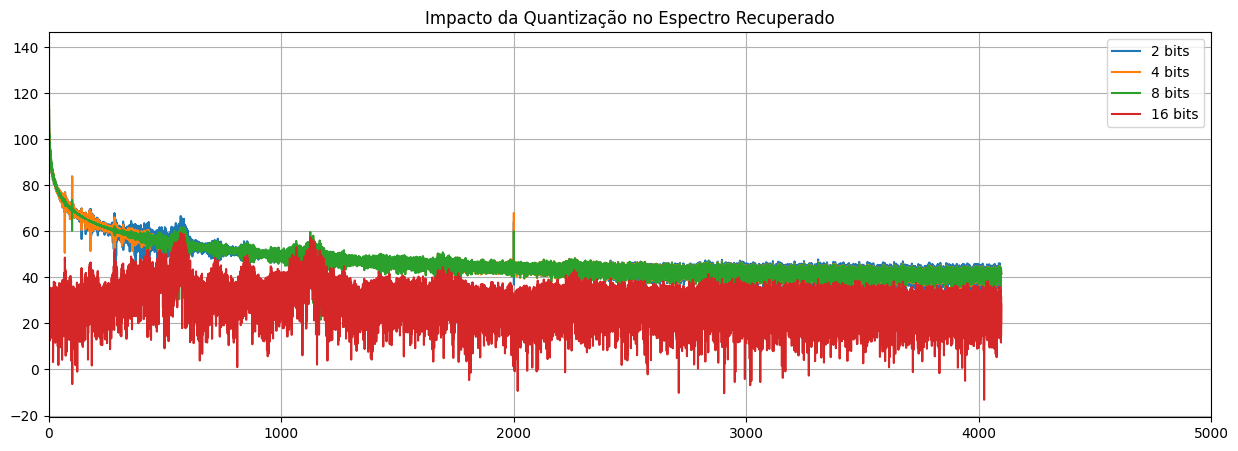

In [13]:
bits_audio = [2, 4, 8, 16]
plt.figure(figsize=(15, 5))

for b_bits in bits_audio:
    # Quantizar coeficientes de ambos os filtros
    b1q, a1q = quantize_coeffs(b1, b_bits), quantize_coeffs(a1, b_bits)
    b2q, a2q = quantize_coeffs(b2, b_bits), quantize_coeffs(a2, b_bits)

    # Filtrar com coeficientes quantizados
    y_q = signal.lfilter(b1q, a1q, y_t_ex)
    y_q = signal.lfilter(b2q, a2q, y_q)

    Y_q_f = fft(y_q)
    plt.plot(freqs[:N//2], 20*np.log10(np.abs(Y_q_f[:N//2]) + 1e-6), label=f'{b_bits} bits')

plt.title('Impacto da Quantização no Espectro Recuperado')
plt.xlim([0, 5000])
plt.legend()
plt.grid()
plt.show()

**Discussão Final (5g):**

1. **Vantagem de Blocos de 2ª Ordem:** A implementação em cascata de SOS (Second-Order Sections) é muito menos sensível a erros de quantização do que a forma direta. Isso ocorre porque os polos de cada bloco estão isolados, evitando que pequenos erros nos coeficientes desloquem todos os polos do sistema global simultaneamente.
2. **Estabilidade:** Para bits muito baixos (2 e 4), o sistema pode divergir ou não filtrar as interferências. A partir de 8 ou 16 bits, o desempenho aproxima-se do ponto flutuante, garantindo a inteligibilidade do áudio.